# SARIMA Forecasting – Waste by Canteen Section

This notebook builds separate SARIMA models for sections **A, B, C, D**.
For each section:
- Hyperparameter tuning via time‑series cross‑validation (walk‑forward)
- Compare tuned model against a baseline (SARIMA(1,1,1)(1,1,1,7))
- Save the best model as a pickle file
- Finally, show a sample usage of loading a model and forecasting future waste

In [7]:
import os
import pickle
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Create directory for saved models
os.makedirs("models/sarima", exist_ok=True)

print("Libraries imported and model directory ready.")

Libraries imported and model directory ready.


## 1. Load and Prepare Data

The dataset `waste_features_full.csv` contains daily waste (kg), foot traffic, holiday flags, and special event flags for each section.

In [8]:
df = pd.read_csv("data/waste_features_full.csv", parse_dates=["date"])
print(f"Full dataset shape: {df.shape}")
print(df.head())

Full dataset shape: (724, 21)
        date section  waste_kg  foot_traffic  waste_organic_kg  \
0 2025-01-01       a     83.48     62.000000             45.95   
1 2025-01-01       b     81.53     57.666667             44.59   
2 2025-01-01       c     74.91     54.250000             41.69   
3 2025-01-01       d     70.73     55.500000             39.05   
4 2025-01-02       a     65.24     51.000000             36.58   

   waste_recyclable_kg  waste_landfill_kg  is_holiday  has_special_event  \
0                25.17              12.35           1                  1   
1                24.43              12.51           1                  1   
2                22.72              10.48           1                  1   
3                21.41              10.25           1                  1   
4                19.43               9.25           0                  1   

   year  ...  day  day_of_week  day_of_year  week_of_year  quarter  \
0  2025  ...    1            2            1   

## 2. Helper Functions

- `prepare_section_data()`: filter section, set date index, split into train/test (last 30 days as test).
- `cross_validate_params()`: walk‑forward grid search over SARIMA orders using RMSE.
- `train_and_evaluate()`: train a SARIMAX model (baseline or tuned) with exogenous regressors and evaluate on test set.
- `plot_forecast()`: visualise actual vs forecast with confidence intervals.

In [9]:
def prepare_section_data(df, section, test_days=30):
    """Filter section, set date index, split into train/test."""
    sec_df = (
        df[df["section"] == section]
        [["date", "waste_kg", "foot_traffic", "is_holiday", "has_special_event"]]
        .set_index("date")
        .sort_index()
        .copy()
    )
    cutoff = sec_df.index.max() - pd.DateOffset(days=test_days)
    train = sec_df[sec_df.index <= cutoff]
    test  = sec_df[sec_df.index >  cutoff]
    return sec_df, train, test


def cross_validate_params(train, param_grid, n_splits=3):
    """
    Walk‑forward cross‑validation grid search for SARIMA orders.
    Splits the training set into n_splits validation folds.
    Returns the best (order, seasonal_order) tuple by mean RMSE.
    """
    all_params = list(itertools.product(
        param_grid["order"],
        param_grid["seasonal_order"]
    ))

    n = len(train)
    fold_size = n // (n_splits + 1)   # each validation chunk size

    results = []
    for order, seasonal_order in all_params:
        fold_rmses = []
        try:
            for k in range(1, n_splits + 1):
                # Training up to the start of validation fold
                train_fold = train.iloc[: k * fold_size]
                val_fold   = train.iloc[k * fold_size : (k + 1) * fold_size]
                if len(val_fold) == 0:
                    continue

                exog_train = train_fold[["foot_traffic", "is_holiday", "has_special_event"]]
                exog_val   = val_fold[["foot_traffic", "is_holiday", "has_special_event"]]

                model = SARIMAX(
                    train_fold["waste_kg"],
                    exog=exog_train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fit = model.fit(disp=False)
                preds = fit.forecast(steps=len(val_fold), exog=exog_val)
                rmse = np.sqrt(mean_squared_error(val_fold["waste_kg"], preds))
                fold_rmses.append(rmse)

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "cv_rmse": np.mean(fold_rmses)
            })
        except Exception:
            continue   # skip unstable configurations

    if not results:
        # fallback to baseline
        return (1, 1, 1), (1, 1, 1, 7)

    best = min(results, key=lambda x: x["cv_rmse"])
    return best["order"], best["seasonal_order"]


def train_and_evaluate(train, test, order, seasonal_order):
    """Train a SARIMAX model and evaluate on test set. Returns model, metrics dict, predictions and confidence interval."""
    exog_train = train[["foot_traffic", "is_holiday", "has_special_event"]]
    exog_test  = test[["foot_traffic", "is_holiday", "has_special_event"]]

    model = SARIMAX(
        train["waste_kg"],
        exog=exog_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)

    forecast_result = fit.get_forecast(steps=len(test), exog=exog_test)
    y_pred = forecast_result.predicted_mean.values
    conf_int = forecast_result.conf_int()
    y_true = test["waste_kg"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return fit, {"rmse": rmse, "mae": mae, "mape": mape}, y_pred, conf_int


def plot_forecast(test, y_pred, conf_int, title, ax):
    """Plot actual vs forecast with confidence interval."""
    ax.plot(test.index, test["waste_kg"], label="Actual", marker="o", markersize=3, color="black")
    ax.plot(test.index, y_pred, label="Forecast", linestyle="--", color="blue")
    ax.fill_between(
        test.index,
        conf_int.iloc[:, 0],
        conf_int.iloc[:, 1],
        alpha=0.2, color="blue", label="95% CI"
    )
    ax.set_title(title)
    ax.set_ylabel("Waste (kg)")
    ax.legend()

print("Helper functions defined.")

Helper functions defined.


## 3. Train & Tune Models for All Sections (A, B, C, D)

For each section:
- Split data (last 30 days = test set)
- Find best hyperparameters via walk‑forward cross‑validation (grid search)
- Train baseline (SARIMA(1,1,1)(1,1,1,7)) and tuned models, evaluate on test
- Save tuned model as pickle
- Store metrics for comparison


Processing Section A
Train size: 151, Test size: 30
Best order: (0, 1, 1), Best seasonal order: (0, 0, 0, 0)
Saved tuned model to models/sarima/sarima_section_a.pkl


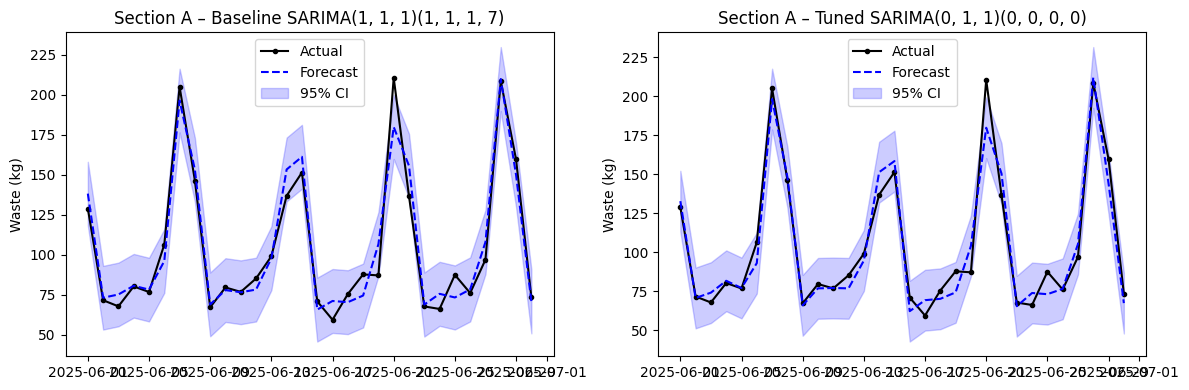


Processing Section B
Train size: 151, Test size: 30
Best order: (1, 1, 1), Best seasonal order: (0, 0, 0, 0)
Saved tuned model to models/sarima/sarima_section_b.pkl


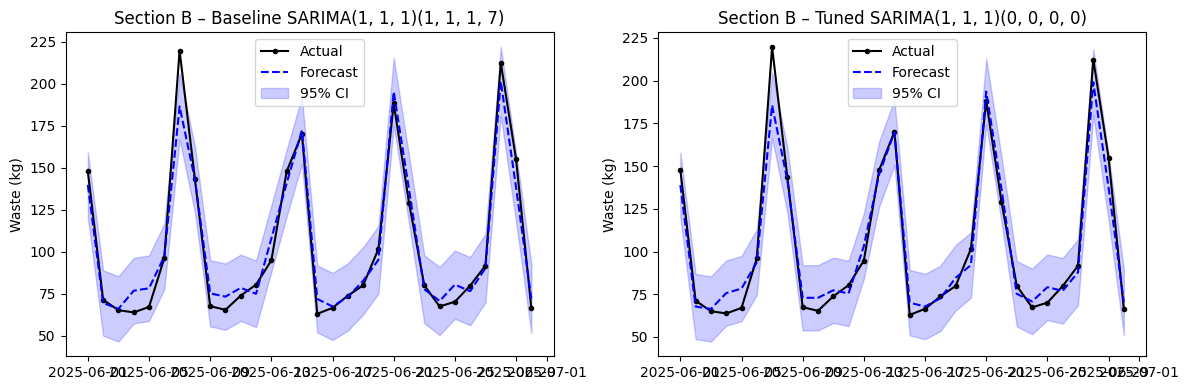


Processing Section C
Train size: 151, Test size: 30
Best order: (1, 1, 1), Best seasonal order: (0, 0, 0, 0)
Saved tuned model to models/sarima/sarima_section_c.pkl


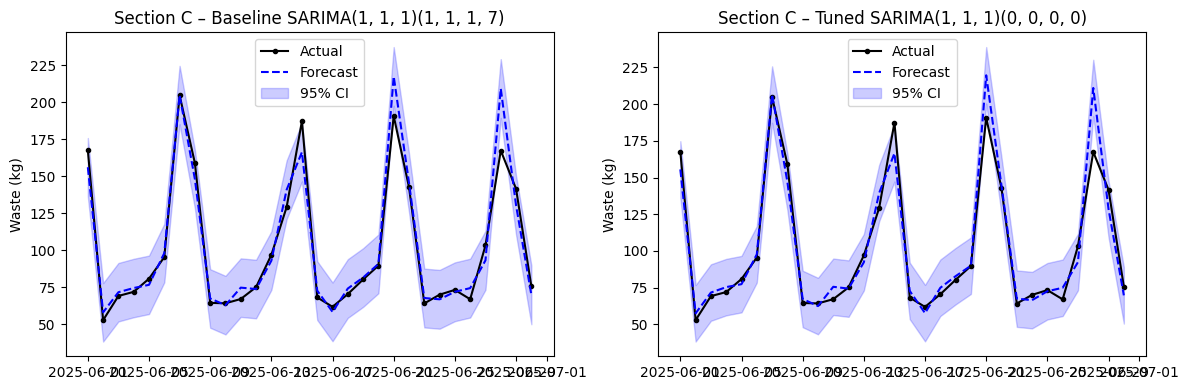


Processing Section D
Train size: 151, Test size: 30
Best order: (1, 1, 0), Best seasonal order: (0, 0, 0, 0)
Saved tuned model to models/sarima/sarima_section_d.pkl


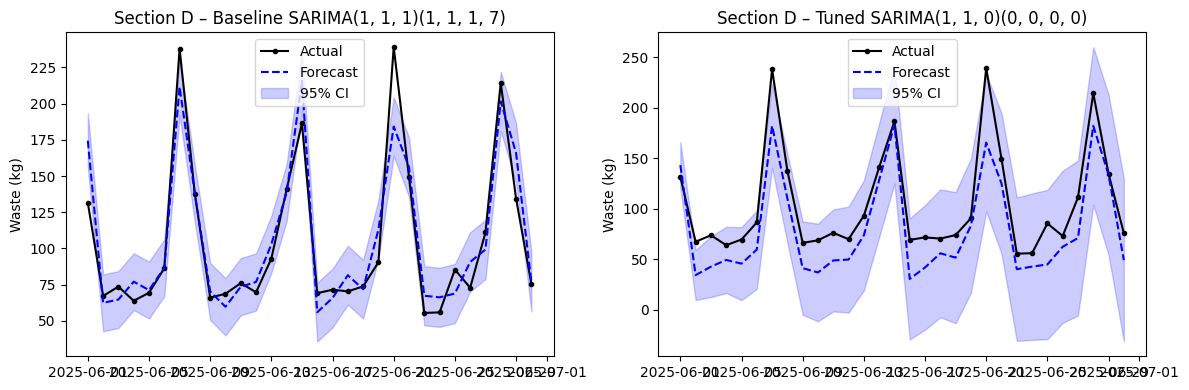


All sections processed.


In [10]:
# Baseline SARIMA orders
BASELINE_ORDER          = (1, 1, 1)
BASELINE_SEASONAL_ORDER = (1, 1, 1, 7)   # weekly seasonality

# Grid to search
param_grid = {
    "order": [
        (1, 1, 1),
        (1, 1, 0),
        (0, 1, 1),
        (2, 1, 1),
        (1, 1, 2),
    ],
    "seasonal_order": [
        (1, 1, 1, 7),
        (1, 1, 0, 7),
        (0, 1, 1, 7),
        (0, 0, 0, 0),   # no seasonal component
    ]
}

sections = ["a", "b", "c", "d"]
results  = []

for section in sections:
    print(f"\n{'='*50}")
    print(f"Processing Section {section.upper()}")
    print('='*50)

    # Prepare data
    _, train, test = prepare_section_data(df, section, test_days=30)
    print(f"Train size: {len(train)}, Test size: {len(test)}")

    # Cross‑validation tuning
    best_order, best_seasonal_order = cross_validate_params(train, param_grid, n_splits=3)
    print(f"Best order: {best_order}, Best seasonal order: {best_seasonal_order}")

    # Baseline model
    baseline_fit, baseline_metrics, baseline_pred, baseline_ci = train_and_evaluate(
        train, test, BASELINE_ORDER, BASELINE_SEASONAL_ORDER
    )

    # Tuned model
    tuned_fit, tuned_metrics, tuned_pred, tuned_ci = train_and_evaluate(
        train, test, best_order, best_seasonal_order
    )

    # Save tuned model
    model_path = f"models/sarima/sarima_section_{section}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(tuned_fit, f)
    print(f"Saved tuned model to {model_path}")

    # Store metrics
    results.append({
        "section":        section.upper(),
        "baseline_rmse":  baseline_metrics["rmse"],
        "tuned_rmse":     tuned_metrics["rmse"],
        "baseline_mae":   baseline_metrics["mae"],
        "tuned_mae":      tuned_metrics["mae"],
        "baseline_mape":  baseline_metrics["mape"],
        "tuned_mape":     tuned_metrics["mape"]
    })

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_forecast(test, baseline_pred, baseline_ci,
                  f"Section {section.upper()} – Baseline SARIMA{BASELINE_ORDER}{BASELINE_SEASONAL_ORDER}",
                  axes[0])
    plot_forecast(test, tuned_pred, tuned_ci,
                  f"Section {section.upper()} – Tuned SARIMA{best_order}{best_seasonal_order}",
                  axes[1])
    plt.tight_layout()
    plt.show()

print("\nAll sections processed.")

## 4. Performance Comparison: Baseline vs Tuned

We summarise RMSE, MAE and MAPE for each section and compute the percentage improvement achieved by tuning.


=== Model Performance Summary ===
section  baseline_rmse  tuned_rmse  baseline_mae  tuned_mae  baseline_mape  tuned_mape  rmse_improvement_%  mae_improvement_%
      A          10.60       10.13          8.00       7.68           7.69        7.46                4.38               4.00
      B           9.43        9.33          6.85       6.75           6.91        6.75                1.15               1.56
      C          11.33       11.84          7.26       7.58           6.43        6.67               -4.54              -4.29
      D          18.23       29.24         13.09      25.17          12.37       27.27              -60.40             -92.28


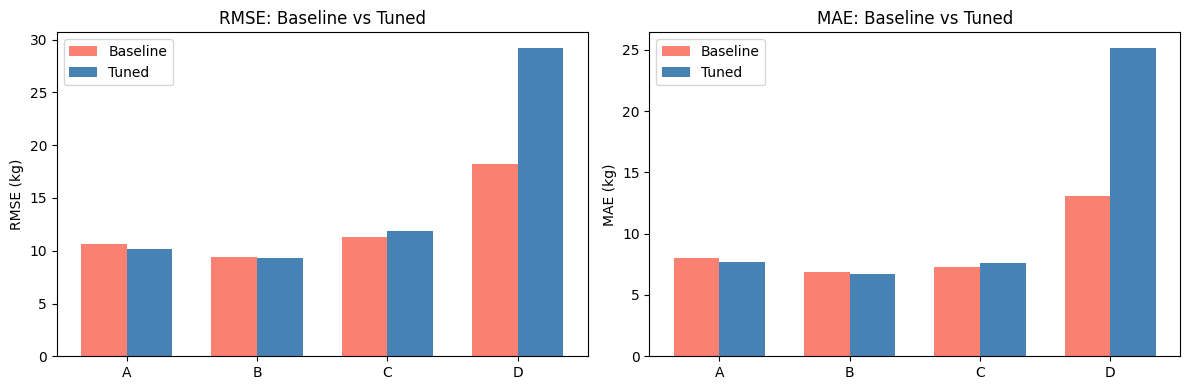

In [11]:
results_df = pd.DataFrame(results)

# Compute improvement (%)
results_df["rmse_improvement_%"] = (
    (results_df["baseline_rmse"] - results_df["tuned_rmse"]) / results_df["baseline_rmse"] * 100
).round(2)
results_df["mae_improvement_%"] = (
    (results_df["baseline_mae"] - results_df["tuned_mae"]) / results_df["baseline_mae"] * 100
).round(2)

print("\n=== Model Performance Summary ===")
print(results_df.round(2).to_string(index=False))

# Bar chart comparison
x = np.arange(len(results_df))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x - width/2, results_df["baseline_rmse"], width, label="Baseline", color="salmon")
axes[0].bar(x + width/2, results_df["tuned_rmse"],    width, label="Tuned",    color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df["section"])
axes[0].set_title("RMSE: Baseline vs Tuned")
axes[0].set_ylabel("RMSE (kg)")
axes[0].legend()

axes[1].bar(x - width/2, results_df["baseline_mae"], width, label="Baseline", color="salmon")
axes[1].bar(x + width/2, results_df["tuned_mae"],    width, label="Tuned",    color="steelblue")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df["section"])
axes[1].set_title("MAE: Baseline vs Tuned")
axes[1].set_ylabel("MAE (kg)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Sample Usage: Load a Saved Model and Forecast Future Waste

Here we demonstrate how to load one of the saved SARIMA models (e.g., section A) and generate a forecast for the next 14 days, using **assumed future values** of the regressors (foot traffic, holidays, events).

Loaded model for section A

14‑day forecast for Section A:
      date  forecast_kg  lower_95  upper_95
2025-07-01         70.8     51.31     90.29
2025-07-02         70.8     51.31     90.29
2025-07-03         70.8     51.31     90.29
2025-07-04         70.8     51.31     90.29
2025-07-05         70.8     51.31     90.29
2025-07-06         70.8     51.31     90.29
2025-07-07         70.8     51.31     90.29
2025-07-08         70.8     51.31     90.29
2025-07-09         70.8     51.31     90.29
2025-07-10         70.8     51.31     90.29
2025-07-11         70.8     51.31     90.29
2025-07-12         70.8     51.31     90.29
2025-07-13         70.8     51.31     90.29
2025-07-14         70.8     51.31     90.29


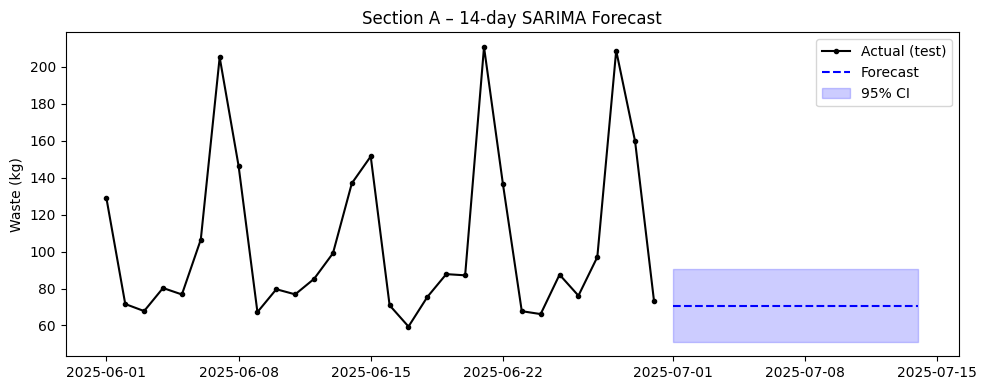

In [12]:
# Load the saved model for section A
model_path = "models/sarima/sarima_section_a.pkl"
with open(model_path, "rb") as f:
    loaded_fit = pickle.load(f)

print("Loaded model for section A")

# Build future exogenous data (14 days)
# In a real scenario these would come from a schedule / calendar.
forecast_horizon = 14

# Get the last date from the original data to start forecast
_, train_a, test_a = prepare_section_data(df, "a", test_days=30)
last_date = test_a.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq="D")

# Example assumed future values
future_exog = pd.DataFrame({
    "foot_traffic":      [55.0] * forecast_horizon,   # replace with actual forecasts
    "is_holiday":        [0]    * forecast_horizon,
    "has_special_event": [0]    * forecast_horizon
}, index=future_dates)

# Forecast
forecast_result = loaded_fit.get_forecast(steps=forecast_horizon, exog=future_exog)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int()

# Display forecast
forecast_df = pd.DataFrame({
    "date":         future_dates,
    "forecast_kg":  forecast_mean.values.round(2),
    "lower_95":     forecast_ci.iloc[:, 0].values.round(2),
    "upper_95":     forecast_ci.iloc[:, 1].values.round(2)
})
print("\n14‑day forecast for Section A:")
print(forecast_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
# Show last 30 days of actuals for context
ax.plot(test_a.index, test_a["waste_kg"], label="Actual (test)", color="black", marker="o", markersize=3)
ax.plot(future_dates, forecast_mean, label="Forecast", color="blue", linestyle="--")
ax.fill_between(
    future_dates,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2, color="blue", label="95% CI"
)
ax.set_title("Section A – 14‑day SARIMA Forecast")
ax.set_ylabel("Waste (kg)")
ax.legend()
plt.tight_layout()
plt.show()